## OS Preparation
Preparing the OS with the required dependencies to run using the specified stack in the requirements.
This includes manually enabling mongodb, running it's service detached, and downloading required files to read earthaccess data formats.

Update repos of the runtime.

In [ ]:
!apt update -y && apt upgrade -y

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
39 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree

Update apt-get and download libhdf to read the format.

In [ ]:
!apt-get update && apt-get install -y libhdf4-dev

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libhdf4-dev is already the newest version (4.2.15-4).
The following packages were automaticall

Importing MongoDB GPG key

In [ ]:
!curl -fsSL https://www.mongodb.org/static/pgp/server-7.0.asc | sudo gpg --dearmor -o /usr/share/keyrings/mongodb-server-7.0.gpg

Add the official MongoDB 7.0 repository for Ubuntu 22.04 (Jammy)

In [ ]:
!echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse" | sudo tee /etc/apt/sources.list.d/mongodb-org-7.0.list

deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse


Update apt and install

In [21]:
!apt-get update && apt-get install -y mongodb-org

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:4 https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 InRelease [3,005 B]
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://cli.github.com/packages stable InRelease
Hit:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0/multiverse arm64 Packages [109 kB]
Get:12 https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0/multiverse amd64 Packages [111 kB]
Fetched 223 kB in 2s (109 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as

Create the default directory MongoDB expects for data

In [22]:
!mkdir -p /data/db

Start the MongoDB daemon in the background (forked)

In [23]:
!mongod --fork --logpath /var/log/mongodb.log

about to fork child process, waiting until server is ready for connections.
forked process: 31060
child process started successfully, parent exiting


## Python Env
All package installations in python using the classic pip

In [ ]:
!pip install earthaccess pyspark xarray netcdf4 pymongo pyhdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.3/780.3 kB 35.4 MB/s eta 0:00:00


## Imports
All imports in one cell to ease re-running.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import earthaccess
import os
import glob
import datetime
from google.colab import userdata
from pymongo import MongoClient
from pyhdf.SD import SD, SDC

## Login and data download
Logging into earth access using a secret token and download the data as HDF4 format.

In [ ]:
# Set credentials as environment variables
os.environ['EARTHDATA_TOKEN'] = userdata.get('earthaccess-login')

# Login
earthaccess.login(strategy="environment")

# Search for MODIS Land Surface Temperature data
# Bounding box covers roughly Egypt; temporal covers 2023
results = earthaccess.search_data(
    short_name="MOD11C1",
    bounding_box=(24.0, 22.0, 37.0, 32.0),
    temporal=("2023-01-01", "2023-12-31"),
    count=15 # Grabbing 15 granules is more than enough for 10k records, I hope.
)

# Download to a local directory
earthaccess.download(results, "./climate_data")

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/15 [00:00<?, ?it/s]

[PosixPath('climate_data/MOD11C1.A2023001.061.2023002173519.hdf'),
 PosixPath('climate_data/MOD11C1.A2023002.061.2023004173943.hdf'),
 PosixPath('climate_data/MOD11C1.A2023003.061.2023006094758.hdf'),
 PosixPath('climate_data/MOD11C1.A2023004.061.2023007093444.hdf'),
 PosixPath('climate_data/MOD11C1.A2023005.061.2023007102341.hdf'),
 PosixPath('climate_data/MOD11C1.A2023006.061.2023010053203.hdf'),
 PosixPath('climate_data/MOD11C1.A2023007.061.2023014233527.hdf'),
 PosixPath('climate_data/MOD11C1.A2023008.061.2023015021147.hdf'),
 PosixPath('climate_data/MOD11C1.A2023009.061.2023015120457.hdf'),
 PosixPath('climate_data/MOD11C1.A2023010.061.2023019102204.hdf'),
 PosixPath('climate_data/MOD11C1.A2023011.061.2023019112122.hdf'),
 PosixPath('climate_data/MOD11C1.A2023012.061.2023019143119.hdf'),
 PosixPath('climate_data/MOD11C1.A2023013.061.2023019163645.hdf'),
 PosixPath('climate_data/MOD11C1.A2023014.061.2023019203647.hdf'),
 PosixPath('climate_data/MOD11C1.A2023015.061.2023019233915.hd

Ingest the data and import into mongodb

In [2]:
hdf_files = glob.glob('./climate_data/*.hdf')

client = MongoClient('localhost', 27017)
db = client['big_data_project']
collection = db['climate_records']

# Clear out any partial inserts from previous crashes
collection.drop()

total_inserted = 0

for file in hdf_files:
    hdf = SD(file, SDC.READ)
    sds = hdf.select('LST_Day_CMG')

    # data is a 3600x7200 global grid.
    data = sds.get()
    attrs = sds.attributes()

    fill_value = attrs.get('_FillValue', 0)
    scale_factor = attrs.get('scale_factor', 0.02)

    # Crop to Egypt's Coordinates
    # Rows 1160 to 1360 (~Lat 32N to 22N), Cols 4080 to 4340 (~Lon 24E to 37E)
    data_crop = data[1160:1360, 4080:4340]

    # Apply the mask only to the cropped area
    valid_mask = data_crop != fill_value
    rows, cols = np.where(valid_mask)
    valid_temps = data_crop[valid_mask] * scale_factor

    filename_only = file.split('/')[-1]
    date_chunk = filename_only.split('.')[1][1:]
    clean_date = datetime.datetime.strptime(date_chunk, '%Y%j').strftime('%Y-%m-%d')

    df_temp = pd.DataFrame({
        'date': clean_date,
        # Add the offset back so the spatial coordinates remain globally accurate
        'grid_row': rows + 1160,
        'grid_col': cols + 4080,
        'temperature_k': valid_temps
    })

    records = df_temp.to_dict(orient='records')

    # --- Batch Insert and Clear RAM ---
    # This in theory prevents OOM crashes
    if records:
        collection.insert_many(records)
        total_inserted += len(records)
        print(f"Inserted {len(records)} records for {clean_date}...")

    # Free memory before the next file loads
    del records
    del df_temp

print(f"\nSuccess! Total records safely stored in MongoDB: {total_inserted}")

Inserted 20380 records for 2023-01-02...
Inserted 36015 records for 2023-01-05...
Inserted 34296 records for 2023-01-12...
Inserted 36522 records for 2023-01-08...
Inserted 37272 records for 2023-01-03...
Inserted 30701 records for 2023-01-04...
Inserted 42715 records for 2023-01-10...
Inserted 35018 records for 2023-01-11...
Inserted 25008 records for 2023-01-07...
Inserted 25530 records for 2023-01-14...
Inserted 39648 records for 2023-01-01...
Inserted 37889 records for 2023-01-06...
Inserted 41145 records for 2023-01-15...
Inserted 40960 records for 2023-01-13...
Inserted 24488 records for 2023-01-09...

Success! Total records safely stored in MongoDB: 507587


## Analysis
`mapReduce` command is deprecated. The modern, highly optimized way to perform MapReduce in MongoDB is using the Aggregation Pipeline (`$group` acts as our Map, and accumulators like `$avg` and `$max` act as our Reduce).

Temporal MapReduce (Average Temperature per Day)

Running Temporal MapReduce...


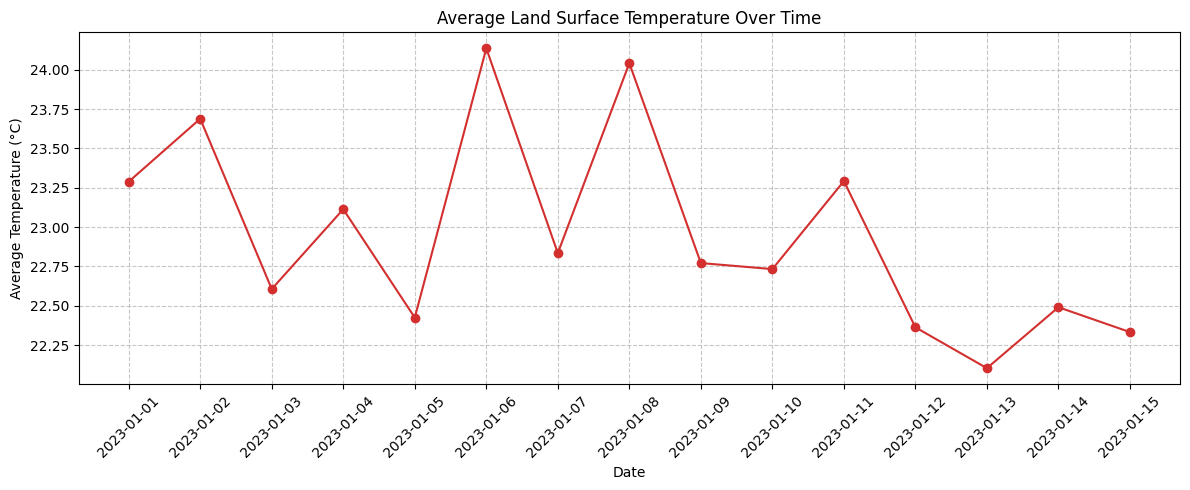

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# MapReduce Job 1: Temporal Aggregation
temporal_pipeline = [
    {"$group": {
        "_id": "$date",
        "avg_temp_k": {"$avg": "$temperature_k"}
    }},
    {"$sort": {"_id": 1}} # Sort chronologically
]

print("Running Temporal MapReduce...")
temporal_results = list(collection.aggregate(temporal_pipeline))

# Convert to Pandas for visualization
df_time = pd.DataFrame(temporal_results)
df_time.columns = ['Date', 'Avg_Temp_K']

# Convert Kelvin to Celsius for a more intuitive presentation, who even uses kelvin
df_time['Avg_Temp_C'] = df_time['Avg_Temp_K'] - 273.15

# Figure setup
plt.figure(figsize=(12, 5))
plt.plot(df_time['Date'], df_time['Avg_Temp_C'], marker='o', linestyle='-', color='#d32f2f')
plt.title('Average Land Surface Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Spatial MapReduce (Maximum Temperature per Area)

Running Spatial MapReduce...


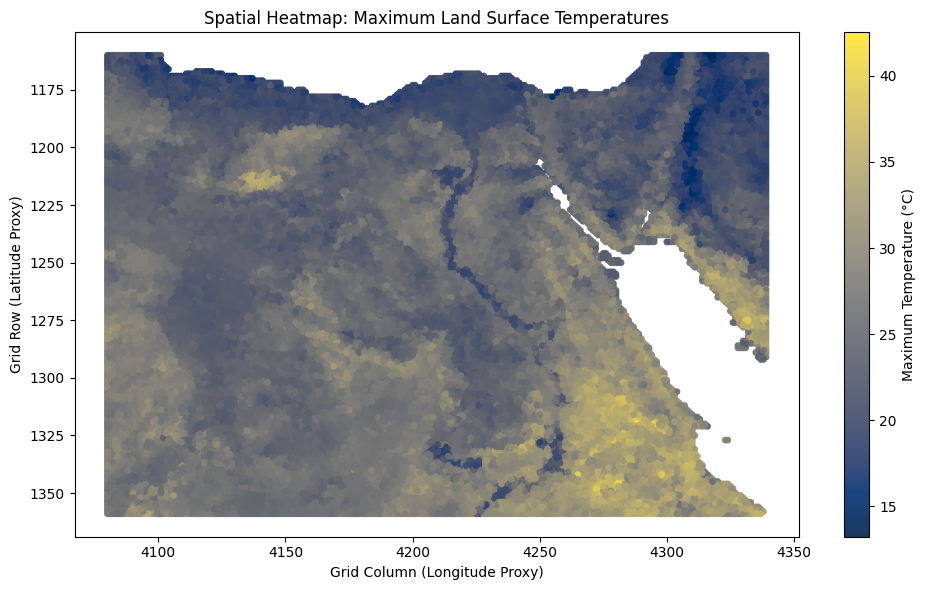

In [9]:
# MapReduce Job 2: Spatial Aggregation
spatial_pipeline = [
    {"$group": {
        "_id": {"row": "$grid_row", "col": "$grid_col"},
        "max_temp_k": {"$max": "$temperature_k"}
    }}
]

print("Running Spatial MapReduce...")
spatial_results = list(collection.aggregate(spatial_pipeline))

# Extract data for the scatter plot heatmap
rows = [doc['_id']['row'] for doc in spatial_results]
cols = [doc['_id']['col'] for doc in spatial_results]
# Convert Kelvin to Celsius, again, who uses eagles per inch?
max_temps_c = [doc['max_temp_k'] - 273.15 for doc in spatial_results]

# Figure 2
plt.figure(figsize=(10, 6))
# Using a scatter plot to simulate a heatmap of the grid
sc = plt.scatter(cols, rows, c=max_temps_c, cmap='cividis', s=15, alpha=0.9)
plt.colorbar(sc, label='Maximum Temperature (°C)')
plt.title('Spatial Heatmap: Maximum Land Surface Temperatures')
plt.xlabel('Grid Column (Longitude Proxy)')
plt.ylabel('Grid Row (Latitude Proxy)')
plt.gca().invert_yaxis() # Invert Y axis to match standard map orientations
plt.tight_layout()
plt.show()

**Feature Engineering: Categorical Binning**  
We can find the maximum temperature for every coordinate but also adds a new phase to the pipeline `($switch)`. We calculate the Celsius value on the fly and dynamically assigns a categorical label ("Cool", "Nominal", "Elevated", or "Extreme Heat") directly inside the database.

Running Feature Engineering Pipeline...


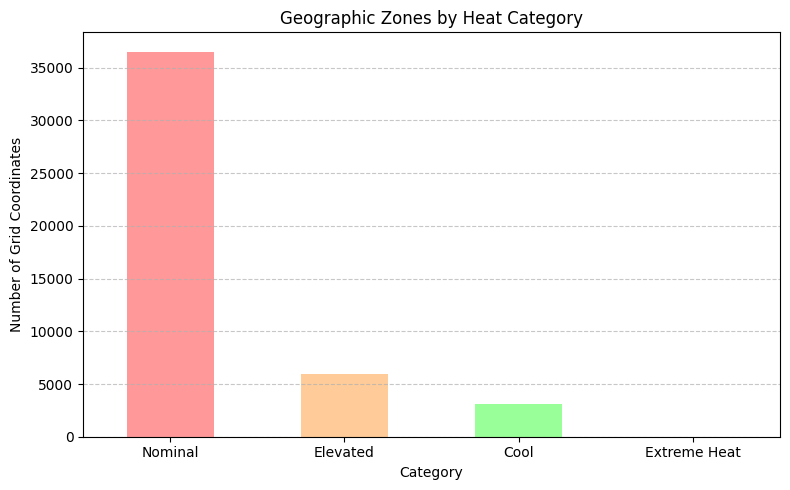


Engineered Data Sample:
    Row   Col  Max_Temp_C Category
0  1279  4106       23.91  Nominal
1  1170  4213       20.51  Nominal
2  1186  4081       26.37  Nominal
3  1218  4236       27.27  Nominal
4  1287  4253       27.33  Nominal


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# MapReduce Job 3: Feature Engineering (Categorical Binning)
feature_pipeline = [
    # 1. The Map & Reduce: Group by location and find the Max Temp in Kelvin
    {"$group": {
        "_id": {"row": "$grid_row", "col": "$grid_col"},
        "max_temp_k": {"$max": "$temperature_k"}
    }},
    # 2. Math: Convert to Celsius for easier binning
    {"$addFields": {
        "max_temp_c": {"$subtract": ["$max_temp_k", 273.15]}
    }},
    # 3. Feature Engineering: Categorize based on the Celsius temperature
    {"$addFields": {
        "heat_category": {
            "$switch": {
                "branches": [
                    {"case": {"$lt": ["$max_temp_c", 20]}, "then": "Cool"},
                    {"case": {"$lt": ["$max_temp_c", 30]}, "then": "Nominal"},
                    {"case": {"$lt": ["$max_temp_c", 40]}, "then": "Elevated"}
                ],
                "default": "Extreme Heat" # Anything 40C and above
            }
        }
    }}
]

print("Running Feature Engineering Pipeline...")
feature_results = list(collection.aggregate(feature_pipeline))

# Convert to Pandas to prove it worked
df_features = pd.DataFrame([
    {
        'Row': doc['_id']['row'],
        'Col': doc['_id']['col'],
        'Max_Temp_C': doc['max_temp_c'],
        'Category': doc['heat_category']
    }
    for doc in feature_results
])

# Quick visualization: Count how many geographic zones fall into each category
category_counts = df_features['Category'].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color=['#ff9999', '#ffcc99', '#99ff99', '#66b3ff'])
plt.title('Geographic Zones by Heat Category')
plt.ylabel('Number of Grid Coordinates')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Show the raw engineered dataframe to the professor
print("\nEngineered Data Sample:")
print(df_features.head())